# The perisomatic cut

Before any unit is built — path or neighbourhood — every node within **5 µm
(Euclidean) of the nucleus** is removed. The radius is `data.soma_restrict.DEFAULT_SOMA_RADIUS_NM`, it is recorded
in every output file as `soma_radius_nm`, and the output directory is named after
it (`r5um/`) so two radii can never be mixed. The soma is shared by every neurite, so a path crossing it would join
branches that are otherwise far apart geodesically, and would describe where the
soma is rather than what the process looks like.

Removing that ball **disconnects the skeleton**, which is the intended outcome: the
primary neurites meet only at the soma, so cutting it leaves roughly one component
per surviving neurite, plus a fragment wherever an arbor re-enters the ball. Every
path is then confined to a single component.

Distance is Euclidean to the nucleus centroid, taken from the store's own `cells`
dimension (`soma_x_nm` / `soma_y_nm` / `soma_z_nm`), keyed by `root_id`. It is a
point in the volume, not a skeleton node, so there is no geodesic distance to it.

**Cells the store has no nucleus position for are built uncut** — every node kept —
rather than excluded. `cut_applied` marks them; section 4 covers them.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

# Root of the database, holding BOTH units: paths/ and neighborhoods/.
from data.build_embedding_paths import DEFAULT_OUT as DB_ROOT
from data.soma_restrict import DEFAULT_SOMA_RADIUS_NM
RADIUS_UM = DEFAULT_SOMA_RADIUS_NM / 1000
S = np.load(REPO_ROOT / "analysis" / "embedding_paths_summary.npz", allow_pickle=False)
CONFIGS = [str(c) for c in S["configs"]]
NCONFIGS = [str(c) for c in S["nconfigs"]]
CABLE = [c for c in NCONFIGS if c.startswith("cable")]
NNODE = [c for c in NCONFIGS if c.startswith("n")]
NPAIRS = [("n10", "cable20um"), ("n20", "cable40um"), ("n40", "cable80um")]
UM = [c for c in CONFIGS if c.endswith("um")]
NODE = [c for c in CONFIGS if c.endswith("node")]

# Matched pairs. Node spacing is ~2 um, so k nodes spans about 2k um -- pairing
# 10node with 10um would compare objects differing two-fold in extent before
# anything about the model is varied. These are the like-for-like comparisons.
PAIRS = [("10node", "20um"), ("20node", "40um"), ("40node", "80um")]

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
})
COLOR = {"cable10um": "#86b6ef", "cable20um": "#2a78d6",
         "cable40um": "#1c5cab", "cable80um": "#0d366b",
         "n10": "#eb6834", "n20": "#e34948", "n40": "#4a3aa7",
         "10um": "#86b6ef", "20um": "#2a78d6", "40um": "#1c5cab", "80um": "#0d366b",
         "10node": "#eb6834", "20node": "#e34948", "40node": "#4a3aa7"}
print(f"{len(CONFIGS)} configs, summary loaded")

7 configs, summary loaded


In [2]:
rid = S["restrict_root_id"]; before = S["restrict_before"]
after = S["restrict_after"]; comps = S["restrict_components"]
ctype = S["restrict_cell_type"]; cut = S["restrict_cut_applied"]
dropped = before - after
R = pd.DataFrame({"root_id": rid, "cell_type": ctype, "before": before,
                  "after": after, "dropped": dropped,
                  "dropped_frac": dropped / np.maximum(before, 1),
                  "components": comps, "cut": cut})
# Everything below describes the *cut* population. An uncut cell trivially keeps
# every node and stays connected, so pooling the two would dilute both numbers.
Rc = R[R["cut"]]
print(f"{len(R):,} cells ({len(Rc):,} cut, {(~R['cut']).sum()} uncut)")
print(f"cut cells: {Rc['before'].sum():,} -> {Rc['after'].sum():,} nodes "
      f"({100*Rc['after'].sum()/Rc['before'].sum():.1f}% kept, "
      f"{Rc['dropped'].sum():,} dropped)")
print(f"components (cut cells): median {Rc['components'].median():.0f}, "
      f"mean {Rc['components'].mean():.1f}, max {Rc['components'].max()}")
Rc.describe().T.style.format("{:,.2f}")

2,335 cells (2,316 cut, 19 uncut)
cut cells: 12,122,132 -> 12,119,220 nodes (100.0% kept, 2,912 dropped)
components (cut cells): median 8, mean 8.0, max 41


,count,mean,std,min,25%,50%,75%,max
root_id,"2,316.00","864,691,135,805,974,400.00","476,157,440.06","864,691,134,884,807,424.00","864,691,135,464,999,808.00","864,691,135,756,737,280.00","864,691,136,090,656,512.00","864,691,137,199,860,096.00"
before,"2,316.00","5,234.08","3,215.92",262.00,"3,386.00","4,586.50","6,031.00","25,434.00"
after,"2,316.00","5,232.82","3,215.85",261.00,"3,385.00","4,585.50","6,030.00","25,433.00"
dropped,"2,316.00",1.26,1.17,0.00,1.00,1.00,1.00,18.00
dropped_frac,"2,316.00",0.00,0.00,0.00,0.00,0.00,0.00,0.01
components,"2,316.00",7.97,3.05,1.00,6.00,8.00,9.00,41.00


## 1. How much of each cell the cut removes

The fraction removed is small for most cells — the ball is 5 µm against arbors that run hundreds of µm — but it is not uniform across types.

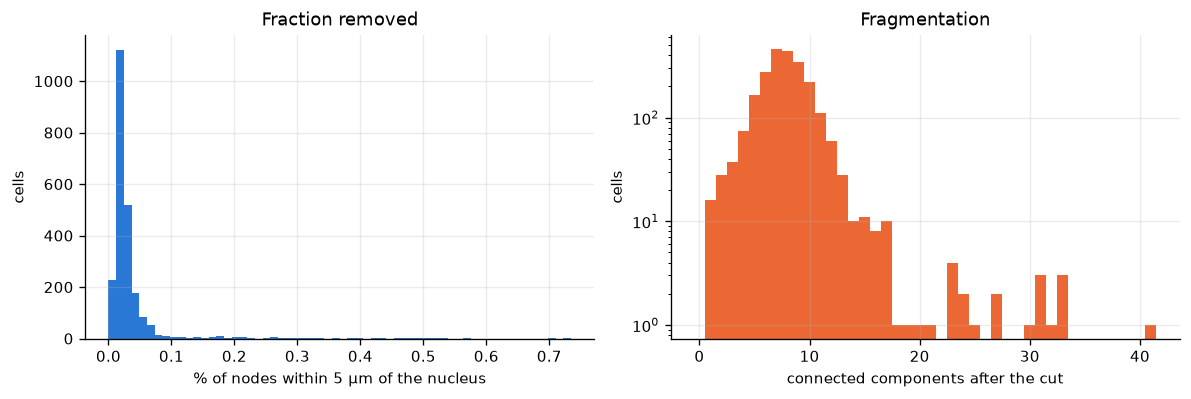

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(Rc["dropped_frac"] * 100, bins=60, color="#2a78d6")
axes[0].set_xlabel(f"% of nodes within {RADIUS_UM:g} µm of the nucleus"); axes[0].set_ylabel("cells")
axes[0].set_title("Fraction removed")
axes[1].hist(Rc["components"], bins=np.arange(0, Rc["components"].max() + 2) - 0.5,
             color="#eb6834")
axes[1].set_xlabel("connected components after the cut"); axes[1].set_ylabel("cells")
axes[1].set_yscale("log"); axes[1].set_title("Fragmentation")
plt.tight_layout(); plt.show()

## 2. Per cell type

Glia fragment far more than neurons: their processes are short and radiate directly from the soma, so even a 5 µm ball severs several of them at once.

In [4]:
g = Rc.groupby("cell_type").agg(
    cells=("root_id", "size"),
    median_before=("before", "median"),
    median_dropped_pct=("dropped_frac", lambda s: 100 * s.median()),
    median_components=("components", "median"),
    max_components=("components", "max"),
).sort_values("median_components", ascending=False)
g.style.format({"cells": "{:.0f}", "median_before": "{:,.0f}",
                "median_dropped_pct": "{:.1f}", "median_components": "{:.0f}",
                "max_components": "{:.0f}"})

,cells,median_before,median_dropped_pct,median_components,max_components
cell_type,,,,,
astrocyte,77,"1,765",0.2,15,41
microglia,30,488,0.2,12,17
L2IT,346,"5,008",0.0,9,16
L5IT,134,"5,981",0.0,9,17
L5ET,58,"5,362",0.0,8,13
PV,174,"11,206",0.0,8,15
NGC,15,"6,801",0.0,8,17
L4IT,546,"4,358",0.0,8,13
L3IT,245,"4,926",0.0,8,16


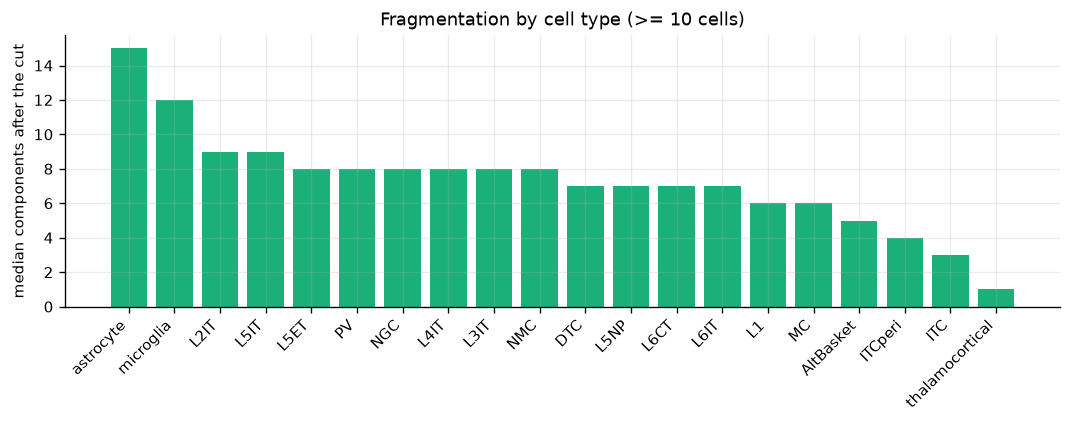

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
sub = g[g["cells"] >= 10]
xs = np.arange(len(sub))
ax.bar(xs, sub["median_components"], color="#1baf7a")
ax.set_xticks(xs); ax.set_xticklabels(sub.index, rotation=45, ha="right")
ax.set_ylabel("median components after the cut")
ax.set_title("Fragmentation by cell type (>= 10 cells)")
plt.tight_layout(); plt.show()

## 3. Does a bigger cell fragment more?

Component count reflects how many processes cross the 5 µm shell, which is a morphology fact rather than a size fact — so the relationship is weak within a type.

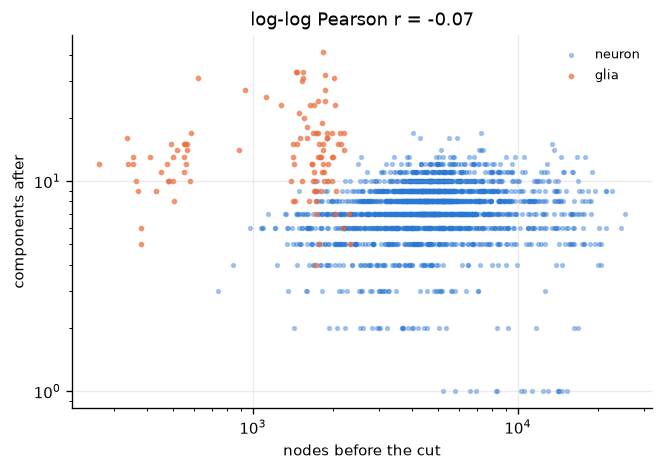

In [6]:
fig, ax = plt.subplots(figsize=(5.6, 4))
glia = np.isin(Rc["cell_type"], ["astrocyte", "microglia", "oligo", "OPC"])
ax.scatter(Rc["before"][~glia], Rc["components"][~glia], s=5, alpha=0.35,
           color="#2a78d6", label="neuron")
ax.scatter(Rc["before"][glia], Rc["components"][glia], s=6, alpha=0.6,
           color="#eb6834", label="glia")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("nodes before the cut"); ax.set_ylabel("components after")
ax.legend(frameon=False, fontsize=8)
r = np.corrcoef(np.log10(Rc["before"]), np.log10(np.maximum(Rc["components"], 1)))[0, 1]
ax.set_title(f"log-log Pearson r = {r:.2f}")
plt.tight_layout(); plt.show()

## 4. What the cut is actually doing

Two measurements together settle this, and neither was obvious in advance.

**Before the cut, every cell is one connected component.** The `graph_cache`
graphs are covered-node subgraphs of a CAVE skeleton, and subsetting to nodes with
embeddings does *not* fragment them — 400/400 cells spanning the whole size range
come back with exactly 1 component. So all the fragmentation below is caused by the
cut, none of it is pre-existing coverage gaps.

**At 5 µm the median cell loses one node and gains eight components.** That is only
possible if the removed node has degree >= 8: the CAVE skeleton represents the soma
as a single high-degree hub that every primary neurite attaches to. Deleting it
disconnects them all at once, which is precisely the intent — and it costs 0.024%
of the nodes to achieve.

A larger radius buys very little extra separation for a lot more data: at 15 µm the
cut removes 34x as many nodes (0.812%) to go from 8 components to 10.

In [7]:
# Degree of the nodes the cut removes, measured on one representative cell.
import torch
from data.geodesic_window import build_csr_from_edges

rid = int(R.sort_values("before", ascending=False).iloc[0]["root_id"])
g = torch.load(REPO_ROOT / "data" / "graph_cache" / f"{rid}.pt", weights_only=False)
with np.load(DB_ROOT / "soma_restricted" / f"{rid}.npz") as z:
    keep, dist = z["keep"], z["dist_to_nucleus_nm"]
n = g.pos.shape[0]
off, nbr, _w = build_csr_from_edges(g.edge_index.numpy(),
                                    g.edge_attr.numpy().reshape(-1), n)
degree = np.diff(off)
removed = np.flatnonzero(~keep)
print(f"cell {rid}: {n:,} nodes, {len(removed)} removed by the {RADIUS_UM:g} µm cut")
print(f"  degree of removed nodes: {sorted(degree[removed].tolist(), reverse=True)}")
print(f"  degree distribution of the whole cell: "
      f"max {degree.max()}, mean {degree.mean():.2f}")
print(f"  components after the cut: "
      f"{int(np.load(DB_ROOT / 'soma_restricted' / f'{rid}.npz')['n_components'][0])}")

/home/jcbliao/rotation/segclr/gnn_classifier/segclr_db/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cell 864691135271970725: 25,434 nodes, 1 removed by the 5 µm cut
  degree of removed nodes: [7]
  degree distribution of the whole cell: max 7, mean 2.00
  components after the cut: 7


### Radius comparison

If the 15 µm build is still on disk, this compares the two directly. The output
directory is named after the radius (`r5um/`, `r15um/`), so both can coexist and
nothing can silently mix them.

In [8]:
rows = []
for tag in ("r5um", "r15um"):
    d = DB_ROOT.parent / tag / "soma_restricted"
    if not d.exists():
        continue
    b = a = 0; drops = []; comps = []
    for f in sorted(d.glob("*.npz")):
        with np.load(f) as z:
            if not bool(z["cut_applied"][0]):
                continue
            bb, aa = int(z["n_nodes_before"][0]), int(z["n_nodes_after"][0])
        b += bb; a += aa; drops.append(bb - aa)
        comps.append(int(np.load(f)["n_components"][0]))
    drops = np.array(drops); comps = np.array(comps)
    rows.append({"radius": tag, "cells": len(drops),
                 "% nodes dropped": 100 * (b - a) / b,
                 "dropped/cell (median)": float(np.median(drops)),
                 "components (median)": float(np.median(comps)),
                 "components (mean)": float(comps.mean())})
pd.DataFrame(rows).set_index("radius").style.format({
    "cells": "{:.0f}", "% nodes dropped": "{:.3f}",
    "dropped/cell (median)": "{:.0f}", "components (median)": "{:.0f}",
    "components (mean)": "{:.2f}"})

,cells,% nodes dropped,dropped/cell (median),components (median),components (mean)
radius,,,,,
r5um,2316,0.024,1,8,7.97
r15um,2316,0.812,29,10,11.83


## 5. Cells built uncut

19 of the 2,335 labelled cells have **no nucleus position** in the store's `cells`
dimension — exactly the 16 oligodendrocytes and 3 OPCs. Every neuron, astrocyte and
microglia has one.

There is no ball to cut for those, so they enter the database **whole**: no node is
removed. Guessing a centre would silently delete some other part of the cell, and
dropping them would shrink the dataset invisibly. `cut_applied` records which
treatment each cell got, so the two populations are never pooled by accident — and
their component counts are *not* comparable to the cut cells' below, since an uncut
skeleton is connected to begin with.

In [9]:
import json
nuc = json.loads((REPO_ROOT / "data" / "nucleus_positions.json").read_text())
cut = S["restrict_cut_applied"]
print(f"cells in database: {len(cut):,}   cut: {cut.sum():,}   uncut: {(~cut).sum():,}")
print("uncut by cell type:", nuc["missing_by_cell_type"])

U = R[~cut]
print()
print(f"uncut cells keep every node: dropped max = {U['dropped'].max()}")
display(U[["root_id", "cell_type", "before", "after", "components"]]
        .sort_values("before", ascending=False).head(10))

cells in database: 2,335   cut: 2,316   uncut: 19
uncut by cell type: {'oligo': 16, 'OPC': 3}

uncut cells keep every node: dropped max = 0


,root_id,cell_type,before,after,components
1077,864691135727846719,OPC,1060,1060,1
2214,864691136725771005,OPC,838,838,1
1376,864691135864397694,OPC,664,664,1
1478,864691135920665264,oligo,605,605,1
894,864691135588675012,oligo,586,586,1
913,864691135593907263,oligo,579,579,1
1463,864691135908742552,oligo,571,571,1
947,864691135620793284,oligo,463,463,1
692,864691135494051472,oligo,365,365,1
1987,864691136324937182,oligo,358,358,1
